# Flashover uncertainty propagation to risk assessment

## Introduction

### Overview

This notebook reproduces the example application presented in Sec 4 of the following paper:

*Franchini, A., Morrisset, D., Emberley, R., and Van Coile, R. On the uncertainty of flashover correlations and its effect on risk assessment. Fire Safety Journal, 2026.*

The example evaluates structural-failure-induced economic losses for an office building. The considered building and the event tree defining the different damage scenarios are visualised below.  

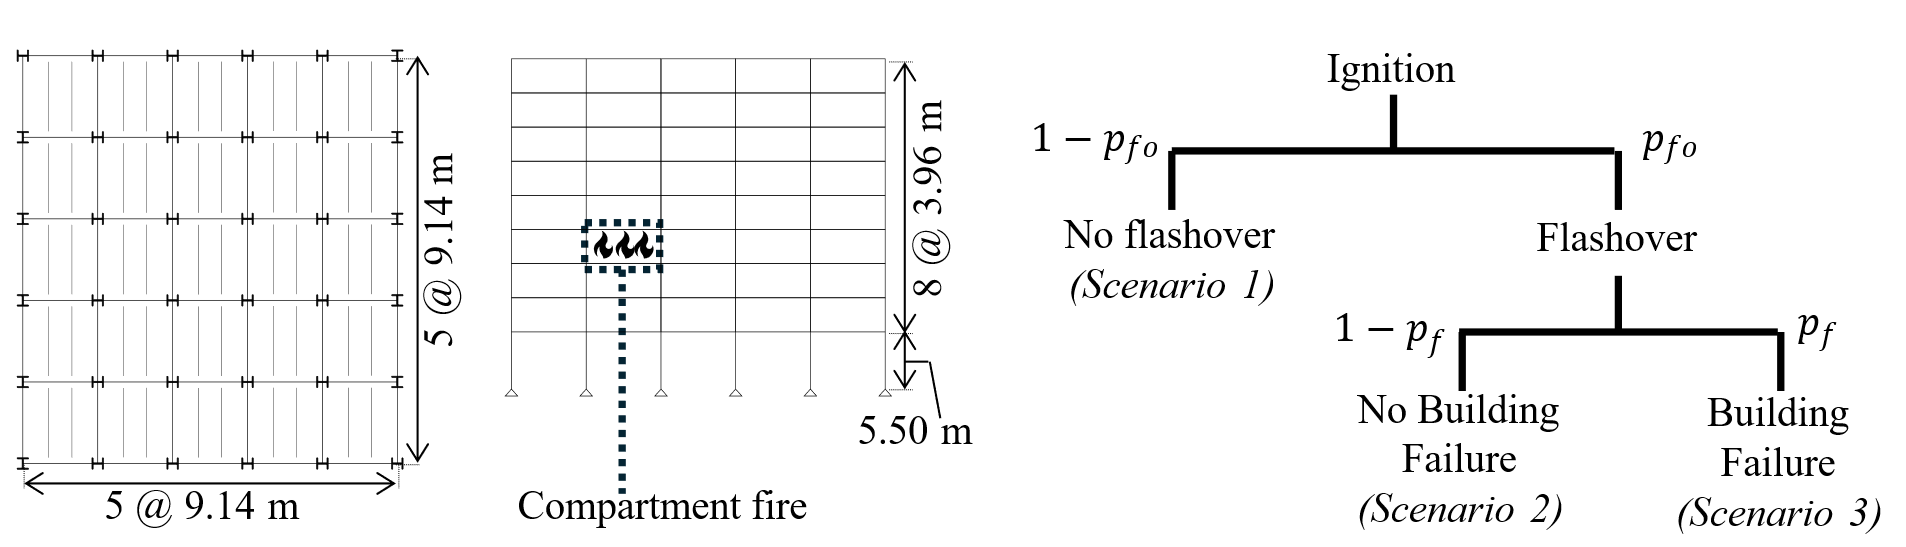

The case study is adapted from :  
*Gernay T, Ni S, Unobe D, Lucherini A, Chaudhary R, Van Coile R, Cost–benefit analysis of fire protection in buildings: application of a present net value approach, Fire technology, 2023;59: 2023-53.*
  
Details on the probabilistic models for consequence calculation are provided in the Appendix of the manuscript.  
References for input data are listed in the manuscript.

### Environment

This notebook was developed and tested using:
* Python 3.12.4
* numpy 2.4.3
* magnelPy 0.3.3
* matplotlib 3.10.8

### Execution
Run all the cells sequentially to reproduce the results and figures.

A fixed random seed is used to ensure reproducibility of stochastic simulations. 

### Note on code release
This notebook illustrates how to calculate a subset of the results presented
in the paper and is provided to support reproducibility. Users may adapt the
methods to other calculations as needed.

**Version history**
| Date | Author | Description |
|------------------|--------|-------------------------------|
| 15 February 2026 | Franchini, A. | Initial release |
| 26 March 2026 | Van Coile, R., Franchini, A. | Reviewed and comments added |

## Notebook initialisation

In [8]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec 

from magnelPy import statFunc as sf
from magnelPy import sampling
from magnelPy import stochVar as sv

Fix seed for reproducibility

In [10]:
np.random.seed(500)

## I. Input

I.I Sampling parameters

In [13]:
# Number of simulations
n_sim = 1000
# Number of random variables
n_rv = 16
# Generate Latin Hypercube Sampling (LHS) matrix
LHS_matrix=sampling.LHS(n_sim, n_rv, RedCor = True, MidPoint = False, Legacy=False )

I.II Construction, demolition, and replacement cost

In [15]:
CoVcosts = 0.3 # [-] Coefficient of variation for Construction cost, Demolition cost and Replacement cost

Construction_Cost = 1674.43 # [USD/m2] Construction cost; evaluated through (RSMeans, 2022)
Construction_Cost = sf.Finv_Normal(LHS_matrix[:,0], Construction_Cost, CoVcosts*Construction_Cost)

Demol_cost = 59.82 # [USD/m2] Demolition cost; evaluated through (RSMeans, 2022)
Demol_cost =sf.Finv_Normal(LHS_matrix[:,1], Demol_cost, CoVcosts*Demol_cost)

Disposal_cost = 0.145 # [USD/m2] Disposal cost; evaluated through (RSMeans, 2022)
Disposal_cost =sf.Finv_Normal(LHS_matrix[:,2], Disposal_cost, CoVcosts*Disposal_cost)

# Unit replacement cost
Replace_cost = Construction_Cost + Demol_cost + Disposal_cost # [USD/m2] replacement cost as sum of demolition, disposal and reconstruction


I.III Valuation of risk to life

Note: VSI fractions are modelled as lognormally distributed with median equal to the NFPA "moderate" fraction.
<br>
For a given CoV, it can be shown that the true mean m of a lognormal distribution having median a is:
<br>
m = a*( 1 + CoV ^2) ^ 0.5 
<br>
This equation is adopted in the next cell.

In [18]:
VSL = 5.657*10**6 # [2022 USD] Value of Statistical Life (VSL); based on (ISO 2394:2015) 

# injury risk
VSI_NFPA = 0.047 # [-] valuation of average injury risk as a fraction of VSL; average injury equals 0.047*VSL based on (Zhuang et al., 2017)
CoV = 1.5 # [-] coefficient of variation for the injury risk
m = VSI_NFPA*(1+CoV**2)**0.5
s = CoV*m
VSI = VSL*sf.Finv_Lognormal(LHS_matrix[:,3], m, s)


I.IV Civilians

In [20]:
# [fatalities/fire]
value_NFPA_businessOffice_2018_2022 = 0.000941088  # 5 civilans deaths / 5313 fires; https://www.nfpa.org/education-and-research/research/nfpa-research/fire-statistical-reports/fires-by-occupancy-or-property-type
m = value_NFPA_businessOffice_2018_2022
CoV = 0.3
s= m*CoV
Nf_civilian = m
Nf_civilian = sf.Finv_Lognormal(LHS_matrix[:,4], m, s)

# [injuries/fire]
mean_NFPA_nonResidential_2000_2023 = 0.0127
value_NFPA_businessOffice_2018_2022 = 0.006775833 # 36 injuries / 5313 fires; https://www.nfpa.org/education-and-research/research/nfpa-research/fire-statistical-reports/fires-by-occupancy-or-property-type 
m = np.mean([mean_NFPA_nonResidential_2000_2023, value_NFPA_businessOffice_2018_2022 ])
CoV = 0.3
s= m*CoV
Nin_civilian = m 
Nin_civilian = sf.Finv_Lognormal(LHS_matrix[:,5], m, s)

I.V Firefighters

In [22]:
#------- [fatalities/fire]

# Firefighters-on ground
mean_NFPA=1.9938e-05;  mean_FEMA=2.2327e-05
m=np.mean([mean_NFPA, mean_FEMA])
CoV = .35
s=m*CoV
Nf_firefighter_on_ground = sf.Finv_Lognormal(LHS_matrix[:,6], m, s)

# Firefighters-response
mean_NFPA=1.3826e-05 ; mean_FEMA = 1.1422e-05
m=np.mean([mean_NFPA, mean_FEMA])
CoV = .35
s=m*CoV
Nf_firefighter_response = sf.Finv_Lognormal(LHS_matrix[:,7], m, s)

#------- [injuries/fire]

# Firefighters-on ground
mean_NFPA = 0.0214
m = mean_NFPA
CoV = .2
s=m*CoV
Nin_firefighter_on_ground = sf.Finv_Lognormal(LHS_matrix[:,8], m, s)

# Firefighters-response
mean_NFPA = 0.0031
m = mean_NFPA
CoV = .15
s=m*CoV
Nin_firefighter_response = sf.Finv_Lognormal(LHS_matrix[:,9], m, s)

I.VI Property loss

In [24]:
#------- Average damage area
S_min = 0; # [m2] min damage area
S_building = 18810 # [m2] total area of the building
S_compartment = 83.5 # [m2] area of a compartment

#----- Scenario 1
S_loss_1 = S_compartment*sf.Finv_Beta(LHS_matrix[:,10],m=None,s=None,alpha=2,beta=5,a=None,b=None)

#----- Scenario 2
S_loss_2 = S_compartment*sf.Finv_Beta(LHS_matrix[:,11],m=None,s=None,alpha=5,beta=1,a=None,b=None)

#----- Scenario 3
S_loss_3 = S_compartment + (S_building-S_compartment)*sf.Finv_Beta(LHS_matrix[:,12],m=None,s=None,alpha=1,beta=5,a=None,b=None)

#----- Property loss multiplication factor for content
eps_loss_content = 2.0 # [-] 
m = 1.
CoVcontent = 0.3
eps_loss_content= 1. + sf.Finv_Lognormal(LHS_matrix[:,13], m, m*CoVcontent)

#----- Property loss multiplication factor for indirect cost
eps_loss_indirect = 1.25 # [-] 
m = 0.25
CoVindirect = 0.7
eps_loss_indirect = 1. + sf.Finv_Lognormal(LHS_matrix[:,14], m, m*CoVindirect)


I.VIII Structural failure probability

In [26]:
pf = 0.79 # [-] probability of structural failure given fire

Plots

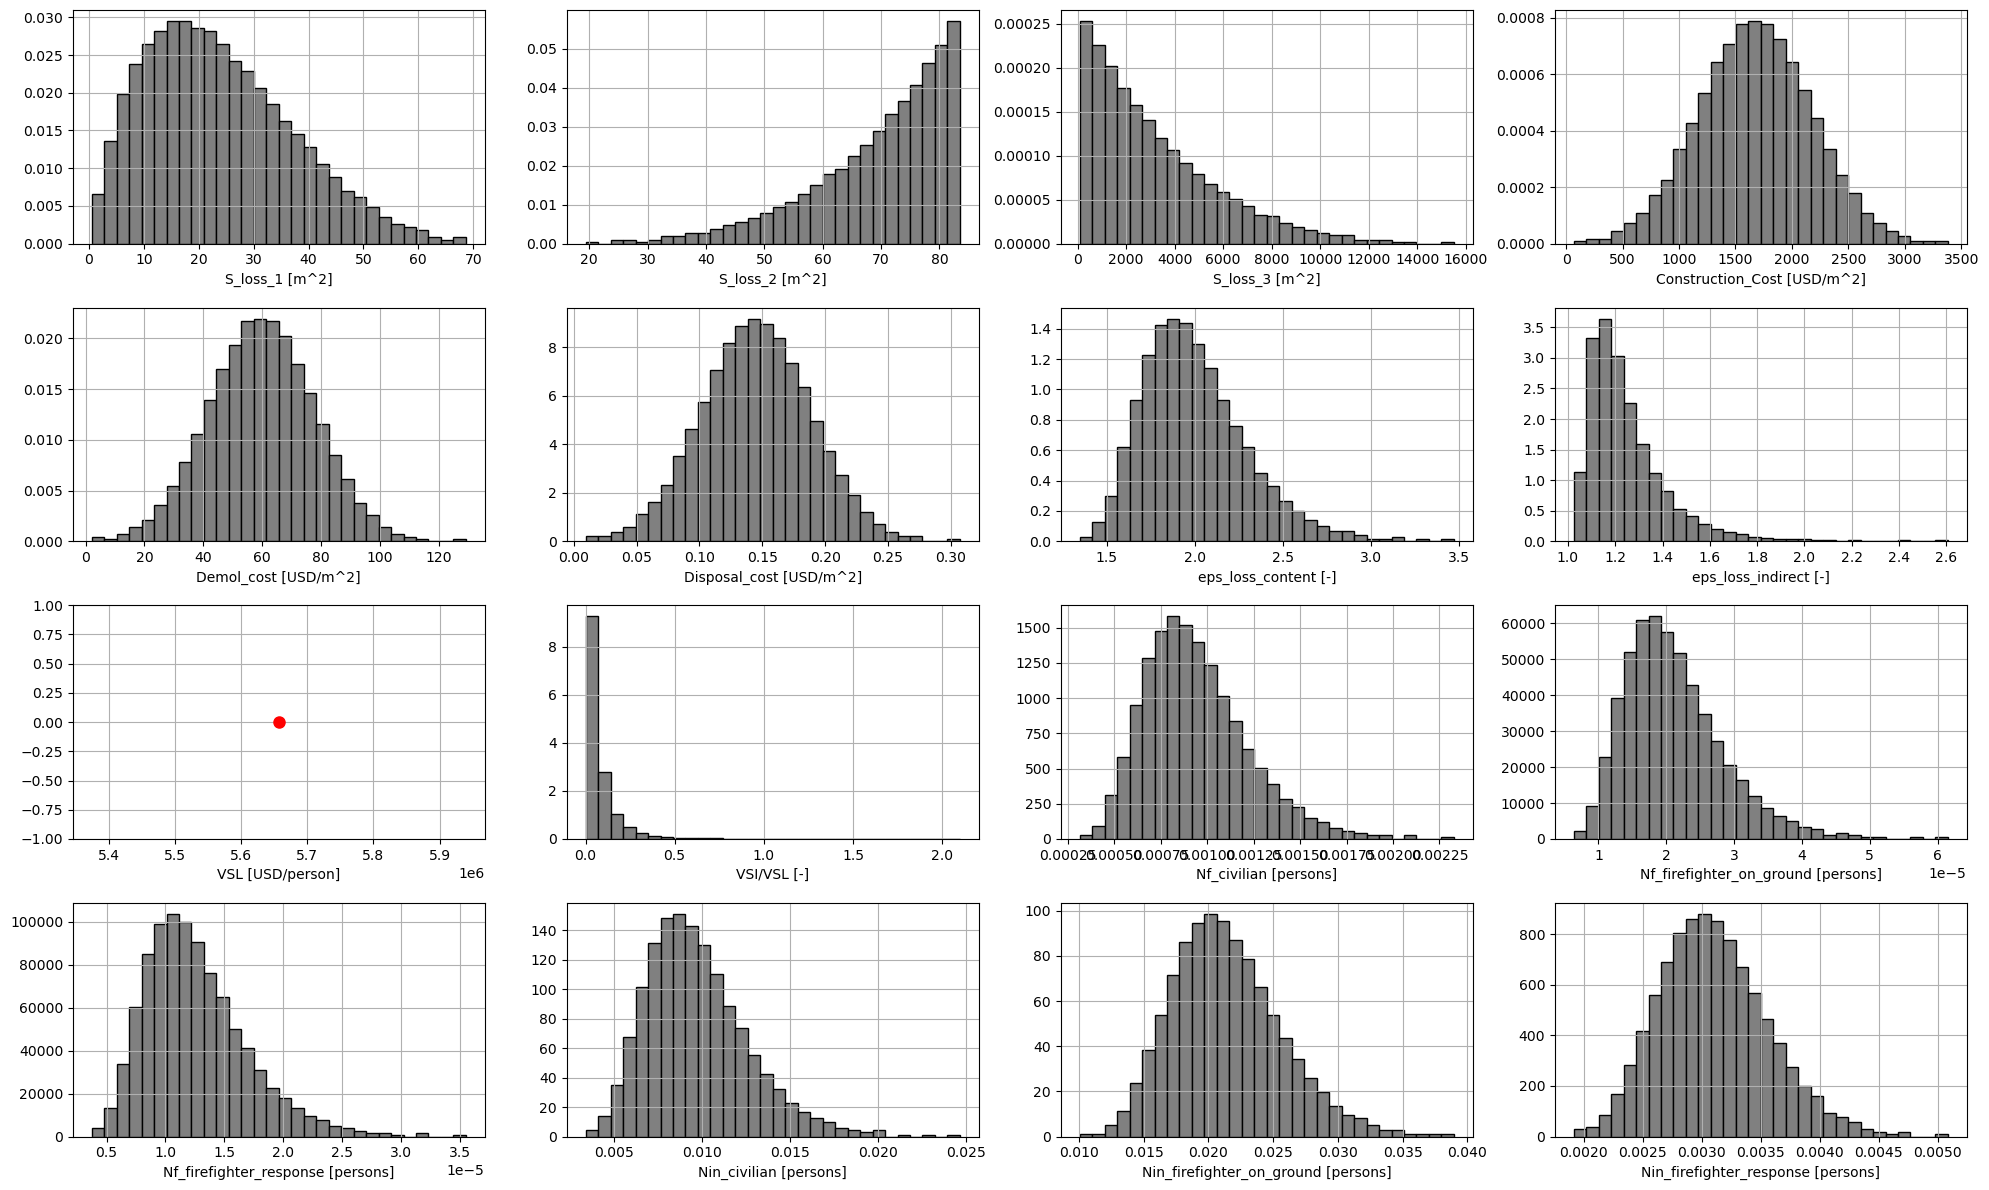

In [28]:
# PLot random and deterministic variables
variables = {
    #"S_area": S_area,
    "S_loss_1 [m^2]": S_loss_1,
    "S_loss_2 [m^2]": S_loss_2,
    "S_loss_3 [m^2]": S_loss_3,
    "Construction_Cost [USD/m^2]": Construction_Cost,
    "Demol_cost [USD/m^2]": Demol_cost,
    "Disposal_cost [USD/m^2]": Disposal_cost,
    "eps_loss_content [-]": eps_loss_content,
    "eps_loss_indirect [-]": eps_loss_indirect,
    "VSL [USD/person]": VSL,
    "VSI/VSL [-]": VSI/VSL,
    "Nf_civilian [persons]": Nf_civilian,
    "Nf_firefighter_on_ground [persons]": Nf_firefighter_on_ground,
    "Nf_firefighter_response [persons]": Nf_firefighter_response,
    "Nin_civilian [persons]": Nin_civilian,
    "Nin_firefighter_on_ground [persons]": Nin_firefighter_on_ground,
    "Nin_firefighter_response [persons]": Nin_firefighter_response,
}


n_vars = len(variables)
ncols = 4
nrows = int(np.ceil(n_vars / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 3*nrows))
axes = axes.flatten()

for i, (name, values) in enumerate(variables.items()):
    ax = axes[i]
    values = np.array(values)

    if values.ndim == 0 or values.size == 1:  
        # Plot a single dot for deterministic values
        ax.plot(values, 0, "ro", markersize=8)  
        ax.set_ylim(-1, 1)
    else:
        # Plot histogram for stochastic values
        ax.hist(values, bins=30, color="gray", edgecolor="black", density=True)
    
    ax.set_xlabel(name)
    ax.grid(True)

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## II. Flashover probability

In [30]:
W = 2. # [m] opening width
H = 2.1 # [m] opening height
VFmax = W*H*H**(0.5)

Peak fuel package HRR

In [32]:
# e.g. large fire
mu_Qp = 2.5*10**3  # [kW] 
sigma_Qp = 0.5*10**3  # [kW]

Qp_rv = sv.createStochVar(name='Qp_rv',dist='lognormal',
                           mean=mu_Qp,
                           std=sigma_Qp)

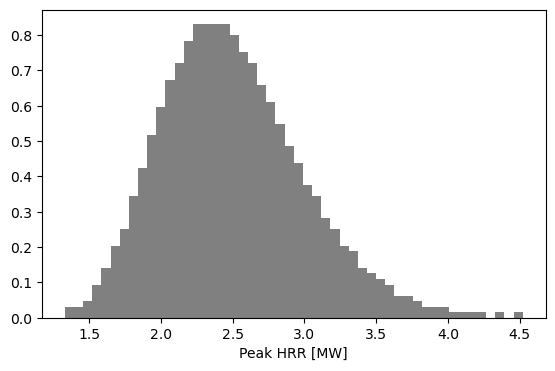

In [33]:
r = np.linspace(0.001,.999,1000)
Qp = sv.Finvx(Qp_rv, r)
plt.figure(figsize=(6.5, 4))
plt.hist(Qp/10**3, bins = 50, density=True, color='gray')
plt.xlabel('Peak HRR [MW]')
plt.show()

Function to calculate flashover probability based on Babrauskas correlation: 

In [35]:
def calc_pfo_Babrauskas_adaptive(VF, Qp_rv,
                                        target_cov=0.05,
                                        n_start=1_000,
                                        n_max=500_000,
                                        plotSamples=True,
                                        plotConvergence=True):
    """
    Calculate flashover probability using Babrauskas criterion
    with adaptive LHS sample size and return a structured output.

    Inputs:
        VF: float or np.array of ventilation factors
        Qp_rv: stochastic variable for peak HRR
        target_cov: convergence criterion for CoV on pfo
        n_start: initial number of LHS samples
        n_max: maximum number of LHS samples
        plotSamples: plot Qfo/Qp distributions
        plotConvergence: plot convergence curves

    Outputs:
        results: np.ndarray with shape (4, len(VF))
                 row 0: pfo_vec
                 row 1: cov_est_vec
                 row 2: convergence flag (1=True, 0=False)
                 row 3: number of simulations used
    """
    VF = np.atleast_1d(VF)
    n_VF = VF.size
    results = np.zeros((4, n_VF), dtype=float)

    for indVF in range(n_VF):
        n_samples = n_start
        ns, pfo_est, cov_est = [], [], []
        convergence = False

        while True:
            LHS_matrix = sampling.LHS(n_samples, 2, RedCor=True, MidPoint=False, Legacy=False)
            
            a_hat = 701.933 # regression result (this is the median; a_mean = a_hat * np.exp(0.5 * sigma_u**2)=753 )
            sigma_u = 0.374 # regression result
            u_samples = sf.Finv_Normal(LHS_matrix[:,0], 0, sigma_u)
            Qfo_samples= a_hat*VF[indVF]*np.exp(u_samples)
            
            Qp_samples = sv.Finvx(Qp_rv, LHS_matrix[:,1])

            flashover_occurs = Qp_samples > Qfo_samples
            pfo_n = np.mean(flashover_occurs)
            cov_n = np.sqrt((1 - pfo_n) / (pfo_n * n_samples)) if pfo_n > 0 else np.inf

            ns.append(n_samples)
            pfo_est.append(pfo_n)
            cov_est.append(cov_n)

            if (n_samples >= n_start) and (cov_n <= target_cov):
                convergence = True
                break
            if n_samples >= n_max:
                print(f"⚠️ Max simulations reached for VF={VF[indVF]} without convergence.")
                break

            n_samples *= 2

        # store results
        results[0, indVF] = pfo_n
        results[1, indVF] = cov_n
        results[2, indVF] = float(convergence)
        results[3, indVF] = n_samples

        # ------------------------ Plot samples ------------------------
        if plotSamples:
            fig = plt.figure(figsize=(6.5, 4))
            gs = gridspec.GridSpec(1, 2, width_ratios=[3,1], wspace=0)
            ax0 = plt.subplot(gs[0])
            VF_vec = np.linspace(0, 10, 1000)
            ax0.plot(VF_vec, 750*VF_vec, color='k', label='Babrauskas correlation')
            ax0.vlines(VF[indVF], 0, max(Qp_samples.max(), Qfo_samples.max()), color='k', linestyle='--', label='Considered VF')
            ax0.scatter(VF[indVF]*np.ones_like(Qfo_samples), Qfo_samples,
                        marker='s', facecolor='none', edgecolor='b', s=70, alpha=0.6, label='Qfo samples')
            ax0.scatter(VF[indVF]*np.ones_like(Qp_samples), Qp_samples,
                        marker='x', color='red', s=20, alpha=0.6, label='Qp samples')
            ax0.set_xlabel('$VF = A*H^{0.5}$')
            ax0.set_ylabel('Q_fo [kW]')
            ax0.legend()
            ax0.grid()
            ax0.set_title(f'pfo = {pfo_n:.4f}, cov = {cov_n:.3f}')

            ax1 = plt.subplot(gs[1], sharey=ax0)
            ax1.hist(Qp_samples, density=True, bins=100, alpha=0.5, orientation='horizontal', color='red')
            ax1.hist(Qfo_samples, density=True, bins=100, alpha=0.5, orientation='horizontal', color='blue')
            ax1.yaxis.set_visible(False)
            ax1.xaxis.set_visible(False)
            plt.tight_layout()
            plt.show()

        # ------------------------ Plot convergence ------------------------
        if plotConvergence:
            fig, ax1 = plt.subplots(figsize=(6.5, 4))
            ax1.plot(ns, pfo_est, 'b-', label='pfo estimate')
            ax1.set_xlabel('Number of simulations')
            ax1.set_ylabel('pfo', color='b')
            ax1.tick_params(axis='y', labelcolor='b')
            ax1.grid(True)
            ax2 = ax1.twinx()
            ax2.plot(ns, cov_est, 'r--', label='CoV of pfo')
            ax2.set_ylabel('CoV', color='r')
            ax2.tick_params(axis='y', labelcolor='r')
            lns = ax1.get_lines() + ax2.get_lines()
            labels = [l.get_label() for l in lns]
            ax1.legend(lns, labels, loc='upper right')
            plt.title(f'Convergence of pfo (VF={VF[indVF]:.2f})')
            plt.tight_layout()
            plt.show()

    return results

Use the function to calculate the flashover probability (pfo) at selected ventilation factor (VF) values.

In this notebook, limited pfo values are calculated for illustration purposes. Then, the results obtained by the authors are provided and used for subsequent calculations. 

A user may run the analysis with their own target ventilation factor values and check that the probability calculation converges.

It is suggested to set plotSamples=False and plotConvergence=False for the full calculation.

*NOTE: flashover probabilities are first calculated at selected VF values, and then interpolation is used to sample pfo realisations conditioned on the sampled ventilation factors. An alternative (less efficient) approach is to directly use the function "calc_pfo_Babrauskas_adaptive" for each sampled VF*

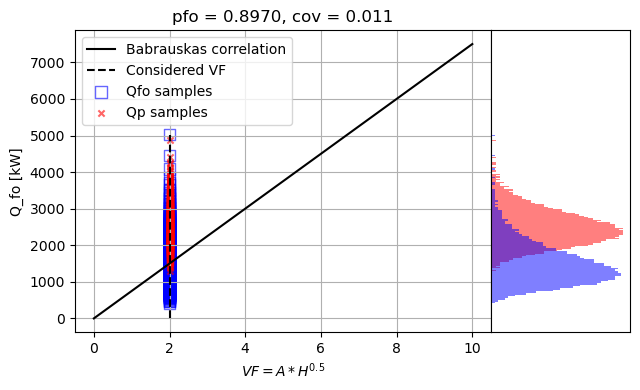

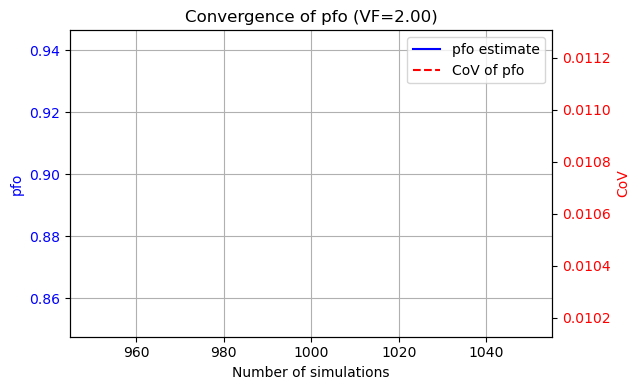

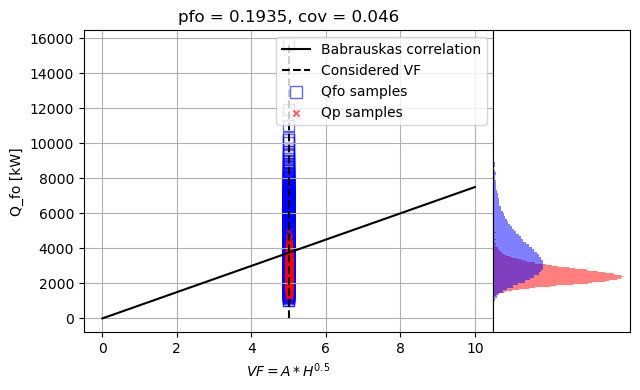

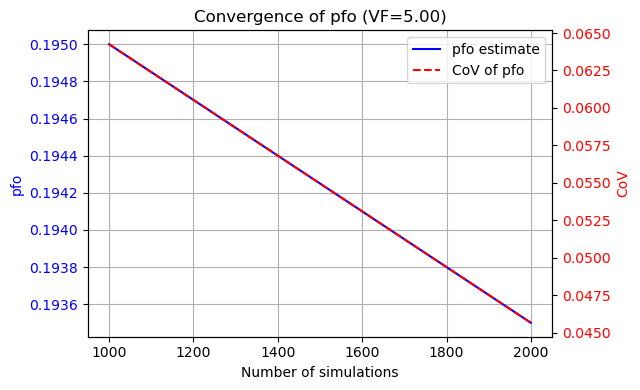

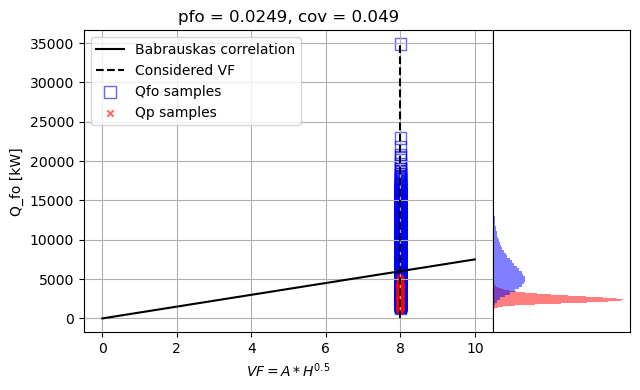

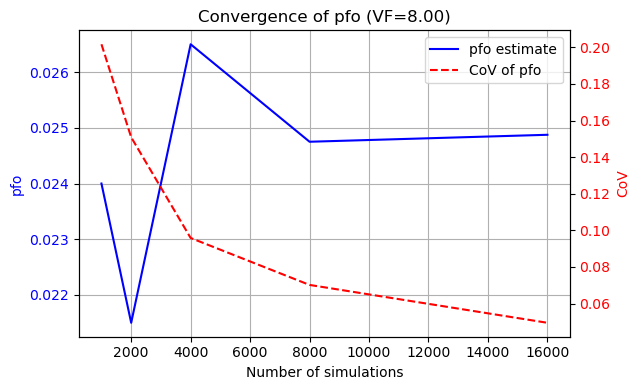

In [37]:
VFvec = np.array([2, 5, 8]) # ventilation factor values. Limited values for illustration
pfo_results = calc_pfo_Babrauskas_adaptive(VFvec, Qp_rv,
                                              target_cov=0.05,
                                              n_start=int(1e3),
                                              n_max=int(1e6),
                                              plotSamples=True,
                                              plotConvergence=True # Note that this plot is empty if convergence is achieved at the first iteration
                                      ) 

pfo_babrauskas_large_fire = pfo_results[0,:]

The following cell contains the authors' results, as presented in the paper. These results are used in the subsequent part of the notebook.

The user can generate their own pfo-vs-VF curves with the code reported above. 


In [39]:
pfo_babrauskas_large_fire = np.array([
    1, 1, 1, 1, 1, 1, 1, 1,
    0.9998, 0.9998, 0.9995, 0.9988, 0.9974, 0.9963, 0.9937, 0.9893,
    0.9864, 0.9806, 0.9717, 0.9655, 0.9563, 0.9458, 0.9297, 0.9183,
    0.9034, 0.8899, 0.8717, 0.8472, 0.829, 0.8065, 0.7836, 0.7646,
    0.7412, 0.7175, 0.6942, 0.6715, 0.65, 0.6276, 0.6006, 0.5772,
    0.5572, 0.5338, 0.5129, 0.4911, 0.467, 0.4431, 0.4276, 0.4092,
    0.3939, 0.3726, 0.3495, 0.3383, 0.3227, 0.3069, 0.2897, 0.2772,
    0.2661, 0.2513, 0.2351, 0.2293, 0.2148, 0.2025, 0.1934, 0.182,
    0.1728, 0.1643, 0.1563, 0.1489, 0.1406, 0.1291, 0.1236, 0.12,
    0.1112, 0.1032, 0.0971, 0.0949, 0.0918, 0.0822, 0.0817, 0.0729,
    0.0715, 0.0674, 0.0619, 0.0612, 0.0564, 0.0508, 0.0536, 0.0506,
    0.0452, 0.042, 0.0427, 0.0394, 0.0385, 0.03575, 0.0327, 0.03185,
    0.02895, 0.0286, 0.0256, 0.0241
])
VFvec = np.array([
    0.1, 0.179798, 0.259596, 0.339394, 0.419192, 0.49899, 0.578788, 0.658586,
    0.738384, 0.818182, 0.89798, 0.977778, 1.05758, 1.13737, 1.21717, 1.29697,
    1.37677, 1.45657, 1.53636, 1.61616, 1.69596, 1.77576, 1.85556, 1.93535,
    2.01515, 2.09495, 2.17475, 2.25455, 2.33434, 2.41414, 2.49394, 2.57374,
    2.65354, 2.73333, 2.81313, 2.89293, 2.97273, 3.05253, 3.13232, 3.21212,
    3.29192, 3.37172, 3.45152, 3.53131, 3.61111, 3.69091, 3.77071, 3.85051,
    3.9303, 4.0101, 4.0899, 4.1697, 4.24949, 4.32929, 4.40909, 4.48889,
    4.56869, 4.64848, 4.72828, 4.80808, 4.88788, 4.96768, 5.04747, 5.12727,
    5.20707, 5.28687, 5.36667, 5.44646, 5.52626, 5.60606, 5.68586, 5.76566,
    5.84545, 5.92525, 6.00505, 6.08485, 6.16465, 6.24444, 6.32424, 6.40404,
    6.48384, 6.56364, 6.64343, 6.72323, 6.80303, 6.88283, 6.96263, 7.04242,
    7.12222, 7.20202, 7.28182, 7.36162, 7.44141, 7.52121, 7.60101, 7.68081,
    7.76061, 7.8404, 7.9202, 8
])

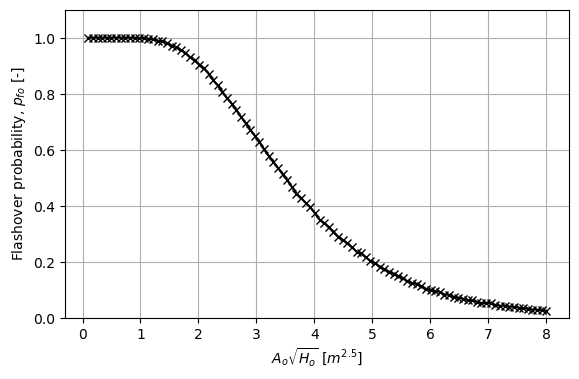

In [40]:
plt.figure(figsize=(6.5, 4))
plt.plot(VFvec, pfo_babrauskas_large_fire, 
         color='k', marker = 'x', linestyle='-')
plt.ylim([0,1.1])
plt.xlabel(r"$A_o \sqrt{H_o}$ $[m^{2.5}]$")
plt.ylabel(r'Flashover probability, $p_{fo}$ [-]')
plt.grid()
plt.show()

Flashover probability distribution

To capture uncertainty in door usage (e.g. 
doors being partially open, closed, or replaced by movable curtain walls  the width is modelle 
as a uniform distribution between 5% and 100% of the total opening, while the height is he d
constant to reflect the single-building scope.

In [43]:
# Sample ventilation factor realisations
VF_realisations = VFmax*( 0.05 +(1-0.05)*LHS_matrix[:,15] )
# Sample flashover probability realisations
pfo_realisations = np.interp(VF_realisations, VFvec, pfo_babrauskas_large_fire)

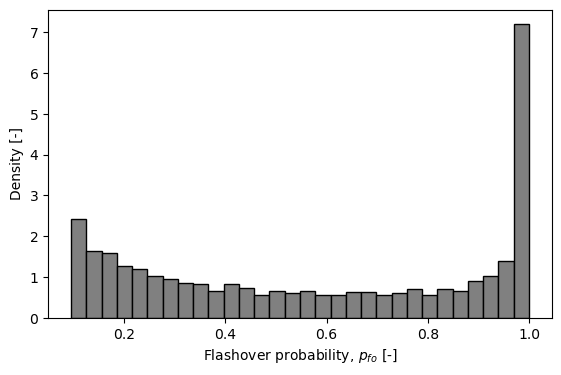

In [44]:
plt.figure(figsize=(6.5, 4))
plt.hist(pfo_realisations, bins=30, density=True,
           facecolor='gray', edgecolor='k')
plt.xlabel(r'Flashover probability, $p_{fo}$ [-]')
plt.ylabel('Density [-]')
plt.show()

## III. Scenario consequence 

In [46]:
def cEi_Scenario1(S_loss, Replace_cost, eps_loss_content, eps_loss_indirect):
    """
    The function returns realisations of scenario 1 (no flashover + minor damage) consequence.
    (Only material loss) 
    """
    #------- Material loss
    xi_d= S_loss * Replace_cost * eps_loss_content * eps_loss_indirect # [USD] property loss

    ### Total loss valuation
    cEi=xi_d # expected value fire-induced loss, scenario "no SFRM"
    
    return cEi

In [47]:
def cEi_Scenario2(Nf_civilian, Nf_firefighter_on_ground, Nf_firefighter_response, 
                  Nin_civilian, Nin_firefighter_on_ground, Nin_firefighter_response,
                  VSL, VSI,
                  S_loss, Replace_cost, eps_loss_content, eps_loss_indirect):
    """
    The function returns realisations of scenario 2 (flashover + no building failure) consequences.
    """

    #------- Fatality rate
    Nf = 0*Nf_civilian + Nf_firefighter_on_ground + Nf_firefighter_response  # [fatality/fire] total fatality rate

    #------- Injury rate
    Nin = Nin_civilian + Nin_firefighter_on_ground + Nin_firefighter_response  # [injury/fire] total injury rate

    #------- Valuation of fatalities and injuries
    # Fatality valuation
    Df=Nf*VSL # [USD/fire] valuation expected life loss
    # Injury valuation
    Din=Nin*VSI # [USD/fire] valuation expected injuries

    #------- Material loss
    xi_d= S_loss * Replace_cost * eps_loss_content * eps_loss_indirect # [USD] property loss

    #------- Total loss valuation
    cEi=Df+Din+xi_d # expected value fire-induced loss, scenario "no SFRM"
    
    return cEi

In [48]:
def cEi_Scenario3(Nf_civilian, Nf_firefighter_on_ground, Nf_firefighter_response, 
                  Nin_civilian, Nin_firefighter_on_ground, Nin_firefighter_response,
                  VSL, VSI,
                  S_loss, Replace_cost, eps_loss_content, eps_loss_indirect):
    """
    The function returns realisations of scenario 3 (flashover + building failure) consequences. 
    """
    #------- Fatality rate
    Nf = Nf_civilian + Nf_firefighter_on_ground + Nf_firefighter_response  # [fatality/fire] total fatality rate

    #------- Injury rate
    Nin = Nin_civilian + Nin_firefighter_on_ground + Nin_firefighter_response # [injury/fire] total injury rate

    #------- Valuation of fatalities and injuries
    # Fatality valuation
    Df=Nf*VSL # [USD/fire] valuation expected life loss
    # Injury valuation
    Din=Nin*VSI # [USD/fire] valuation expected injuries

    #------- Material loss
    xi_d= S_loss * Replace_cost * eps_loss_content * eps_loss_indirect # [USD] property loss

    #------- Total loss valuation
    cEi=Df+Din+xi_d 
        
    return cEi

In [49]:
cE1 = cEi_Scenario1(S_loss_1, Replace_cost, eps_loss_content, eps_loss_indirect)

cE2 = cEi_Scenario2(Nf_civilian, Nf_firefighter_on_ground, Nf_firefighter_response, 
                  Nin_civilian, Nin_firefighter_on_ground, Nin_firefighter_response,
                  VSL, VSI,
                  S_loss_2, Replace_cost, eps_loss_content, eps_loss_indirect)

cE3 = cEi_Scenario3(Nf_civilian, Nf_firefighter_on_ground, Nf_firefighter_response, 
                  Nin_civilian, Nin_firefighter_on_ground, Nin_firefighter_response,
                  VSL, VSI,
                  S_loss_3, Replace_cost, eps_loss_content, eps_loss_indirect)


## IV. Stochastic event-tree CCDFs

In [51]:
# Create a 3d array ("Consequence-Frequency" matrix) containing all the realisations
n_events = 3 # number of considered events in the event tree
CFmatrix_random = np.zeros((n_events, 3, n_sim ))

CFmatrix_random[0,0,:] = cE3
CFmatrix_random[1,0,:] = cE2
CFmatrix_random[2,0,:] = cE1

CFmatrix_random[0,1,:] = pfo_realisations*pf
CFmatrix_random[1,1,:] = pfo_realisations*(1-pf)
CFmatrix_random[2,1,:] = 1-pfo_realisations

for i in range(0, n_sim):
    # get sort order based on column 0
    order = np.argsort(CFmatrix_random[:,0,i])
    # apply order to all columns of the slice
    CFmatrix_random[:,:,i] = CFmatrix_random[order,:,i]
    # Fill third column: reverse cumulative sum
    CFmatrix_random[:,2,i] = np.cumsum(CFmatrix_random[::-1,1,i])[::-1]
    

## V. Loss exceedance function

In [53]:
# Grid of consequences to evaluate CCDF on
xgrid = np.logspace(1, 8, 500) 

# Store CCDF across simulations
all_ccdfs = np.zeros((n_sim, len(xgrid)))

for i in range(n_sim):
    # extract consequences and exceedance prob for this simulation
    x = CFmatrix_random[:,0,i]
    y = CFmatrix_random[:,2,i]

    # For each xgrid, check the exceedance probability
    # by finding the largest y where consequence >= threshold
    for j, xv in enumerate(xgrid):
        mask = x >= xv
        if np.any(mask):
            all_ccdfs[i, j] = np.max(y[mask])  # still in exceedance
        else:
            all_ccdfs[i, j] = 0.0              # above max consequence → prob = 0

# Mean CCDF across simulations
mean_ccdf = np.mean(all_ccdfs, axis=0)

# Quantiles for uncertainty bands
lower_ccdf = np.percentile(all_ccdfs, 2.5, axis=0)   # 2.5th percentile
upper_ccdf = np.percentile(all_ccdfs, 97.5, axis=0)  # 97.5th percentile

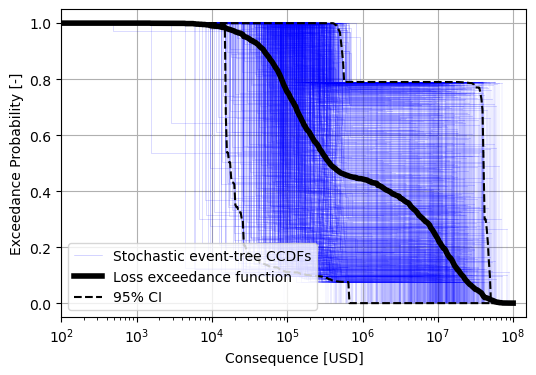

In [54]:
plt.figure(figsize=(6,4))

for i in range(0, n_sim): 
    x=CFmatrix_random[:,0,i]
    y=CFmatrix_random[:,2,i]
    plt.step(x,y, where="pre", color='b', linewidth=0.5, alpha=0.2)
    #add horizontal line at the beginning and vertical line at the end
    plt.plot( [x[-1], x[-1]], [y[-1], 0.], color='b', linewidth=0.25, alpha=0.2)
    plt.plot( [0, x[0]], [y[0], y[0]] , color='b', linewidth=0.25, alpha=0.2)
    
plt.plot( [0, x[0]], [y[0], y[0]] , color='b', 
          linewidth=0.4, alpha=0.3, label='Stochastic event-tree CCDFs')


plt.plot(xgrid, mean_ccdf, color="k", linewidth=4, label="Loss exceedance function")


plt.plot(xgrid, lower_ccdf, color="k", 
          linestyle='--', linewidth=1.5, label="95% CI")

plt.plot(xgrid, upper_ccdf, color="k", 
          linestyle='--', linewidth=1.5)

plt.xscale("log")
plt.xlim([10**2, 1.5*10**8])
plt.xlabel("Consequence [USD]")
plt.ylabel("Exceedance Probability [-]")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()